In [96]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
# from fastlisaresponse import ResponseWrapper
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path

Not on GPU


In [97]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable')

KeyboardInterrupt: 

In [ ]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 1
qS = 0.5
phiS = 1
qK = 1 #fixed
phiK = phiS + np.pi/3#FIXED
Phi_phi0 = 0.4#FIXED
Phi_theta0 =0.2
Phi_r0 = 0.5

dt = 10.0
T = 0.5

chi2 = 0.8

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=False
p0=9.0

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

#param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']
param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0'] #works
#rhvae to take qK and phiK constant for it to run
#'Phi_phi0',"Phi_theta0",'Phi_r0' derivatives are present analytically it says

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev_0_p":dev_0_p,
"dev_0_e":dev_0_e,"dev_1_p":dev_1_p,"dev_1_e":dev_1_e,"dev_2_p":dev_2_p,"dev_2_e":dev_2_e}

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)


wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 9.0, 0.4, 1.0, 1, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.2, 0.5, 0.8, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


np.float64(634.4387474970785)

T:  0.5 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 9.0, 0.4, 1.0, 1, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.2, 0.5, 0.8, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 634.4387474970785
calculating stable deltas...
Gamma_ii for m1: 9835.599254507062
Gamma_ii for m1: 9835.599254477353
Gamma_ii for m1: 9835.59925369285
Gamma_ii for m1: 9835.599252728647
Gamma_ii for m1: 9835.599222185816
Gamma_ii for m1: 9835.59920122353
Gamma_ii for m1: 9835.598301034648
Gamma_ii for m1: 9835.603783374367
[np.float64(3.0206145207258336e-12), np.float64(7.976157066522685e-11), np.float64(9.803191471088851e-11), np.float64(3.105335065503181e-09), np.float64(2.131266870185385e-09), np.float64(9.152355083858402e-08), np.float64(5.573973737992467e-07)]
0


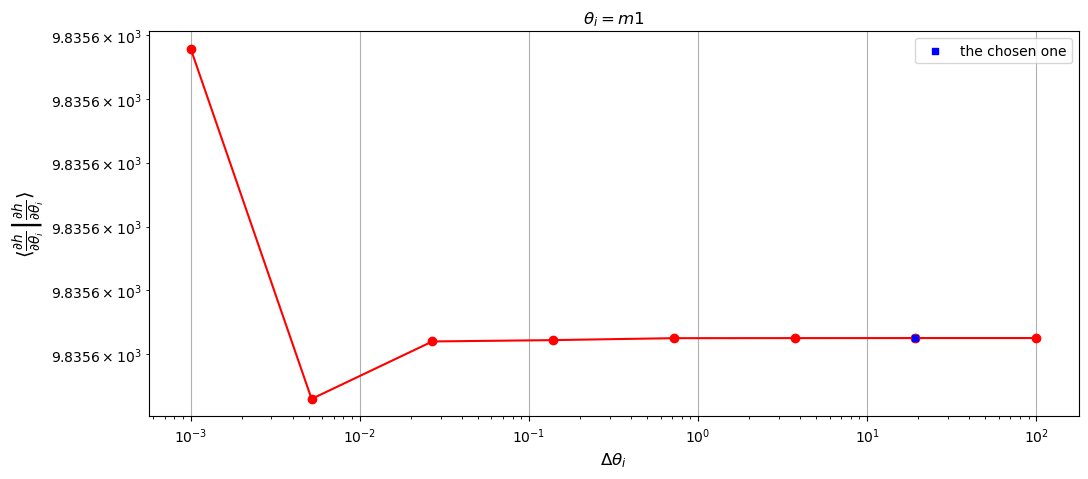

Gamma_ii for m2: 188188705404.43826
Gamma_ii for m2: 188188705184.17114
Gamma_ii for m2: 188188705458.6748
Gamma_ii for m2: 188188704507.57294
Gamma_ii for m2: 188188716995.4461
Gamma_ii for m2: 188188757364.4756
Gamma_ii for m2: 188188506950.59775
Gamma_ii for m2: 188188756963.84744
[np.float64(1.1704587698064205e-09), np.float64(1.4586617270166328e-09), np.float64(5.053979568882721e-09), np.float64(6.635824595821811e-08), np.float64(2.145135025350932e-07), np.float64(1.3306544692650763e-06), np.float64(1.3285238381315933e-06)]
0


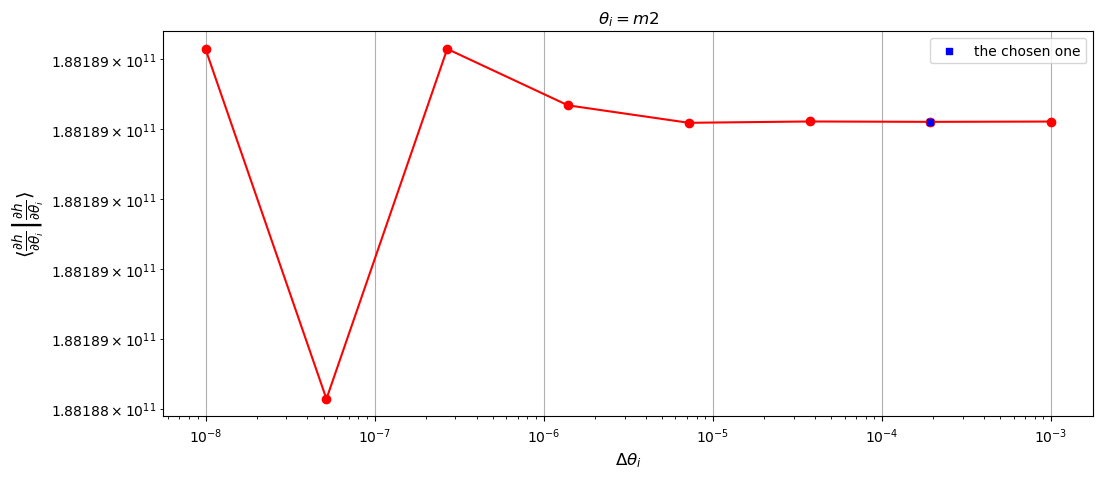

Gamma_ii for p0: 267871068275432.47
Gamma_ii for p0: 267870979709933.3
Gamma_ii for p0: 267872021164467.72
Gamma_ii for p0: 267872807080988.8
Gamma_ii for p0: 267817232422428.78
Gamma_ii for p0: 268423415171011.62
Gamma_ii for p0: 268240840389921.28
Gamma_ii for p0: 268801094201058.72
[np.float64(3.306274507681049e-07), np.float64(3.887880973454929e-06), np.float64(2.9339167706415813e-06), np.float64(0.0002075096440111561), np.float64(0.002258308010113972), np.float64(0.0006806375227014227), np.float64(0.0020842690867857)]
0


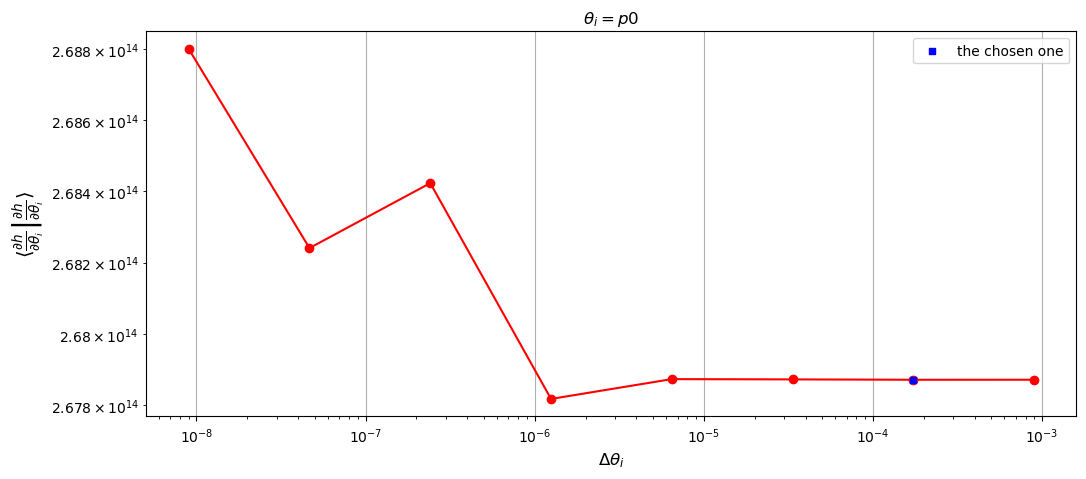

Gamma_ii for e0: 9940406191000524.0
Gamma_ii for e0: 9940429564851552.0
Gamma_ii for e0: 9940437449496358.0
Gamma_ii for e0: 9940431443343588.0
Gamma_ii for e0: 9931493821888362.0
Gamma_ii for e0: 1.0007834427473984e+16
Gamma_ii for e0: 9661428485823788.0
Gamma_ii for e0: 1.0226233823374814e+16
[np.float64(2.351392449944799e-06), np.float64(7.931889160873381e-07), np.float64(6.042144955410261e-07), np.float64(0.0008999272028471757), np.float64(0.007628084391169396), np.float64(0.03585452629064919), np.float64(0.055231021244596536)]
2


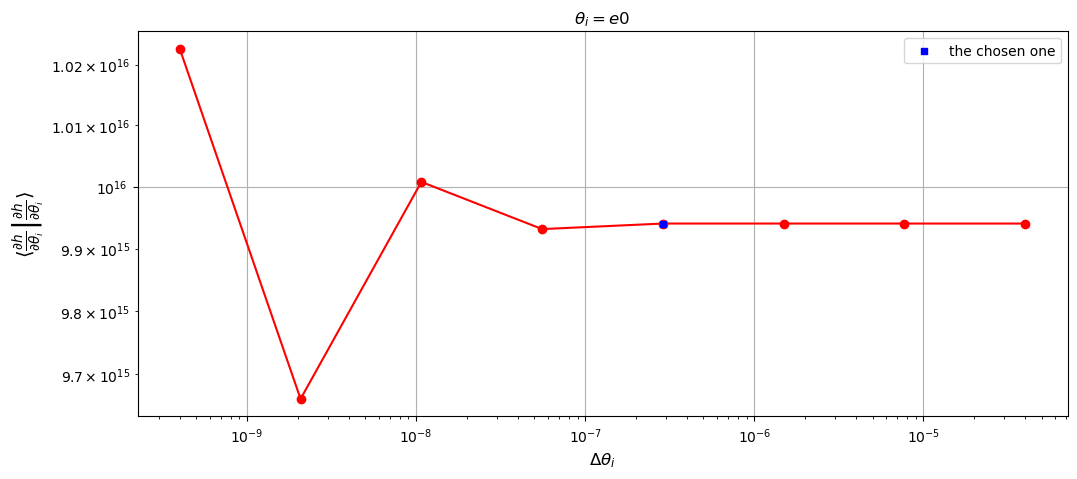

Gamma_ii for qS: 1333808.6587863443
Gamma_ii for qS: 1333808.658903041
Gamma_ii for qS: 1333808.658903051
Gamma_ii for qS: 1333808.6589030433
Gamma_ii for qS: 1333808.6589029997
Gamma_ii for qS: 1333808.6589028917
Gamma_ii for qS: 1333808.6589061725
Gamma_ii for qS: 1333808.6589014577
[np.float64(8.749124581365591e-11), np.float64(7.506112372482435e-15), np.float64(5.760504843998181e-15), np.float64(3.2642860782657426e-14), np.float64(8.09961893216806e-14), np.float64(2.4597355683814525e-12), np.float64(3.534855245184904e-12)]
2


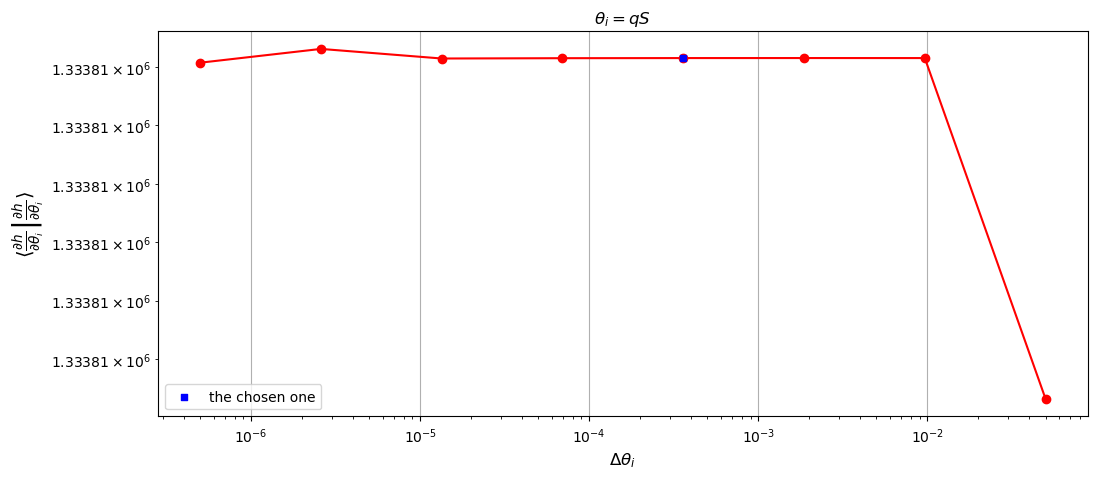

Gamma_ii for phiS: 1511138.8634594437
Gamma_ii for phiS: 1511138.9016553808
Gamma_ii for phiS: 1511138.9016573562
Gamma_ii for phiS: 1511138.9016573778
Gamma_ii for phiS: 1511138.9016580519
Gamma_ii for phiS: 1511138.9016589122
Gamma_ii for phiS: 1511138.901670437
Gamma_ii for phiS: 1511138.901724708
[np.float64(2.5276258278838045e-08), np.float64(1.307183064768541e-12), np.float64(1.4329093001352262e-14), np.float64(4.4605079826770205e-13), np.float64(5.693118133327188e-13), np.float64(7.626621230836624e-12), np.float64(3.591394565292887e-11)]
2


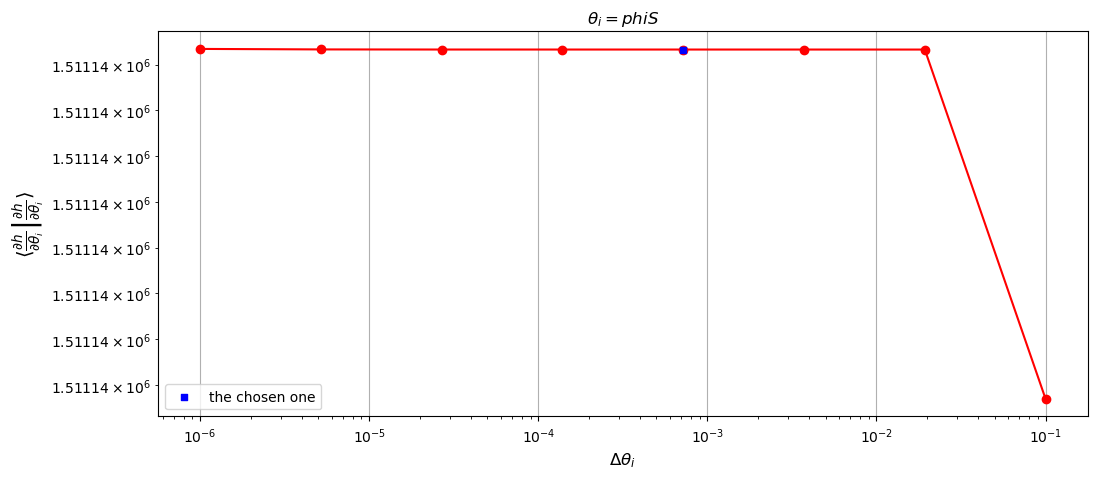

stable deltas: {'m1': 19.306977288832496, 'm2': 0.00019306977288832496, 'p0': 0.00017376279559949242, 'e0': 2.878742692004612e-07, 'dist': 0.0, 'qS': 0.00035984283650057603, 'phiS': 0.0007196856730011522, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 346.95060682296753 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 69.62684988975525 seconds


In [ ]:
der_order = 6
Ndelta = 8
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    qS = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    # qK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
)

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
          #   delta_range = delta_range,
            live_dangerously = False)

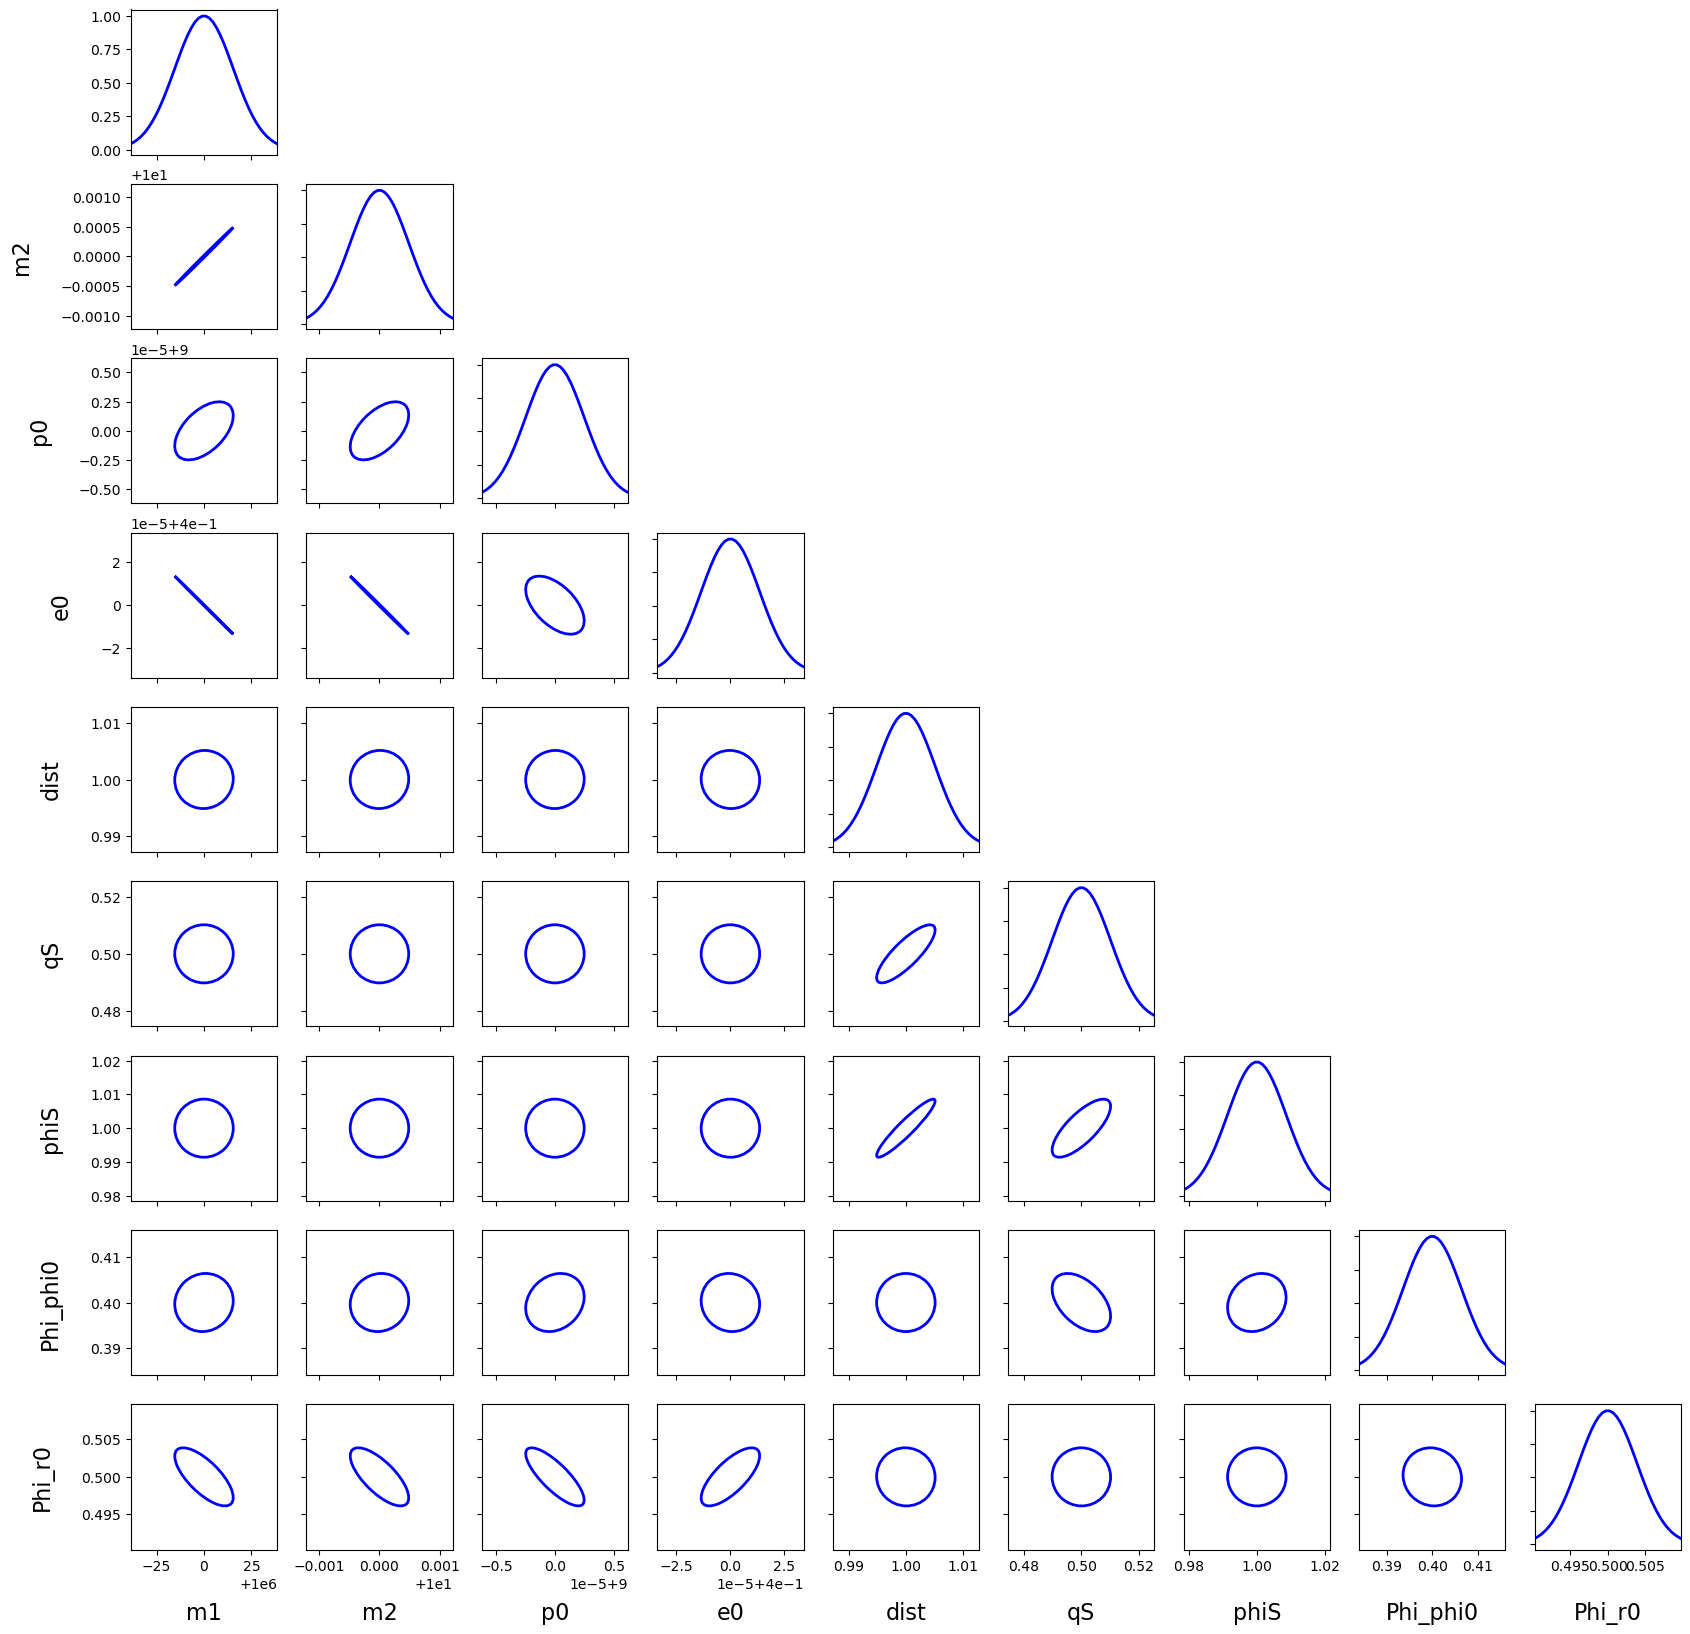

In [ ]:

from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0]
param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0']
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
param_names = param_names

covariance = np.linalg.inv(Fisher)

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)



In [ ]:
np.sqrt(covariance[5][5])

np.float64(0.010151731463785466)

In [ ]:
np.savetxt("../../Results/Covariance_first_sampling_data.txt",covariance)

In [ ]:
covariance.shape

(9, 9)